# Grad-CAM Explainer Demo

This notebook demonstrates how to use Grad-CAM to explain slide grade predictions.

**What is Grad-CAM?**
- Gradient-weighted Class Activation Mapping
- Highlights which parts of the image the model focused on
- Helps understand WHY the model made a prediction

**How it works:**
1. Model makes a prediction
2. Grad-CAM analyzes which image regions influenced that prediction
3. Creates a heatmap overlay showing important regions

---

## 1. Setup

In [1]:
import sys
from pathlib import Path
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

# Add project src to path
project_root = Path('../')
sys.path.insert(0, str(project_root / 'src'))

from models.slide_grade_time_recommender import create_grade_time_model
from data.stain_time_transforms import get_stain_time_val_transforms
from evaluation.gradcam_explainer import GradeExplainer
from utils.configuration import (
    get_model_path,
    DEFAULT_IMAGE_SIZE,
    NUM_GRADE_CLASSES,
    DEFAULT_ARCHITECTURE
)

# Create output directory for saving plots
OUTPUT_DIR = project_root / 'results' / 'results_04' / 'figures' / 'gradcam' / 'gradcam_notebook'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Libraries loaded successfully")
print(f"✓ Output directory: {OUTPUT_DIR}")

✓ Libraries loaded successfully
✓ Output directory: ..\results\results_04\figures\gradcam\gradcam_notebook


## 2. Load Model

In [2]:
# Configuration
MODEL_PATH = get_model_path()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Device: {DEVICE}")
print(f"Loading model from: {MODEL_PATH}")

# Load model (dual-head: grade + time)
model = create_grade_time_model(
    architecture=DEFAULT_ARCHITECTURE,
    num_grade_classes=NUM_GRADE_CLASSES,
    pretrained=False,
    use_time_context=True
)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("✓ Model loaded successfully (dual-head: grade + time)")

# Create explainer
explainer = GradeExplainer(model, device=DEVICE)
print("✓ Grad-CAM explainer initialized")

Device: cpu
Loading model from: c:\Users\Sayumi Devasurendra\Desktop\AMC\anti_malaria_campaign\notebooks\..\models\models_04\model-01\best_model.pth
✓ Model loaded successfully (dual-head: grade + time)
✓ Grad-CAM explainer initialized


## 3. Load Test Images

In [3]:
# Check if test.csv exists, otherwise use val.csv
test_csv_path = project_root / 'data' / 'data_04' / 'splits' / 'test.csv'
val_csv_path = project_root / 'data' / 'data_04' / 'splits' / 'val_optimal.csv'

if test_csv_path.exists():
    test_df = pd.read_csv(test_csv_path)
    split_name = "test"
elif val_csv_path.exists():
    test_df = pd.read_csv(val_csv_path)
    split_name = "validation"
else:
    raise FileNotFoundError("Neither test.csv nor val_optimal.csv found!")

print(f"Using {split_name} set: {len(test_df)} images")
print(f"\nGrade distribution:")
print(test_df['grade_numeric'].value_counts().sort_index())

# Select sample images (one from each grade)
sample_images = []
for grade in sorted(test_df['grade_numeric'].unique()):
    grade_samples = test_df[test_df['grade_numeric'] == grade]
    if len(grade_samples) > 0:
        sample = grade_samples.iloc[0]
        sample_images.append(sample)

print(f"\n✓ Selected {len(sample_images)} sample images (one per grade)")

Using validation set: 32 images

Grade distribution:
grade_numeric
2     8
3     3
4    14
5     7
Name: count, dtype: int64

✓ Selected 4 sample images (one per grade)


## 4. Generate Grad-CAM Explanations

In [4]:
# Image preprocessing transform
transform = get_stain_time_val_transforms(DEFAULT_IMAGE_SIZE)

# Process each sample
explanations = []

for idx, sample in enumerate(sample_images):
    print(f"\nProcessing image {idx+1}/{len(sample_images)}: {sample['filename']}")
    
    # Load image
    image_path = Path(sample['filepath'] if 'filepath' in sample else sample['filename'])
    if not image_path.exists():
        # Try relative to project root
        image_path = project_root / sample['filename']
    
    image = Image.open(image_path).convert('RGB')
    image_np = np.array(image)
    
    # Preprocess
    image_tensor = transform(image).unsqueeze(0)
    
    # Prepare stain time tensor (from the sample metadata)
    stain_time = sample['time_minutes'] if 'time_minutes' in sample else 10.0
    stain_time_tensor = torch.tensor([stain_time], dtype=torch.float32)
    
    # Generate explanation with current_time parameter
    explanation = explainer.explain(image_tensor, image_np, stain_time_tensor)
    
    # Store results
    explanations.append({
        'sample': sample,
        'image': image_np,
        'explanation': explanation,
        'stain_time': stain_time
    })
    
    print(f"  True Grade: {sample['grade_numeric']}")
    print(f"  Stain Time: {stain_time} minutes")
    print(f"  Predicted Grade: {explanation['grade_numeric']}")
    print(f"  Status: {explanation['status']}")
    print(f"  Confidence: {explanation['confidence']:.2%}")
    print(f"  Reason: {explanation['reason']}")

print("\n✓ All explanations generated")


Processing image 1/4: data/data_04/processed/batch08_3%_26min_2_thick.jpg
  True Grade: 2
  Stain Time: 26 minutes
  Predicted Grade: 4
  Status: FAIL
  Confidence: 42.87%
  Reason: Model detected high staining intensity with strong background signals. Model detected high intensity signals in background regions.

Processing image 2/4: data/data_04/processed/batch08_3%_30min_3_thick.jpg
  True Grade: 3
  Stain Time: 30 minutes
  Predicted Grade: 4
  Status: FAIL
  Confidence: 35.26%
  Reason: Model detected high staining intensity with strong background signals. Model detected high intensity signals in background regions.

Processing image 3/4: data/data_04/processed/batch08_3%_31min_4_thin.jpg
  True Grade: 4
  Stain Time: 31 minutes
  Predicted Grade: 2
  Status: FAIL
  Confidence: 41.16%
  Reason: Model detected low staining intensity with limited color contrast. Sparse activation pattern - model focused on limited regions with weak intensity signals, consistent with under-staining.

## 5. Visualize Results

✓ Saved to: ..\results\results_04\figures\gradcam\gradcam_notebook\sample_1_grade2_20260101_213329.png


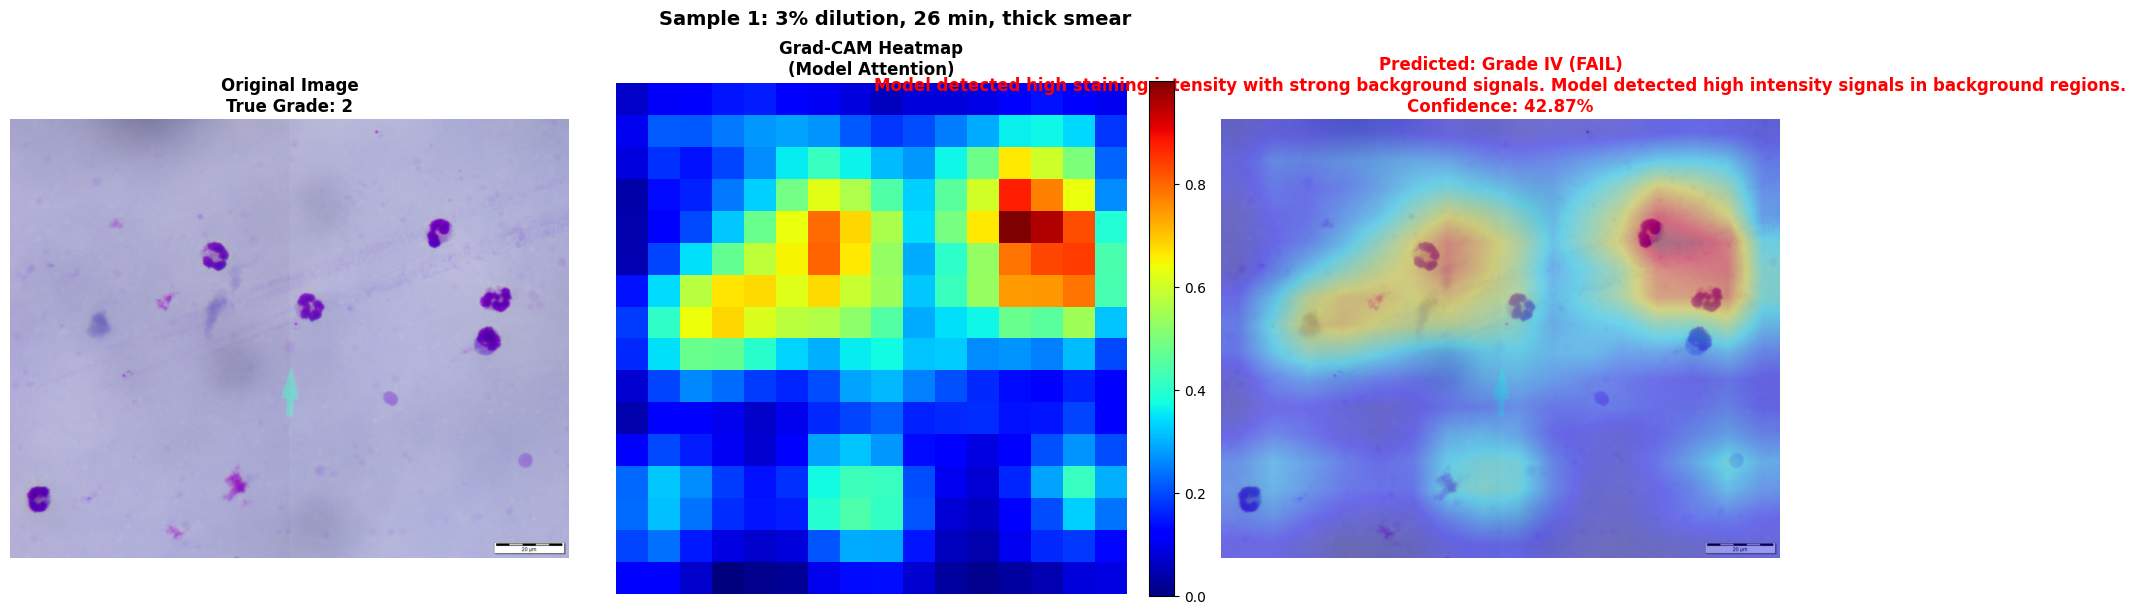


Sample 1 - Probability Breakdown:
  Grade I:  0.92% 
  Grade II: 10.70% █████
  Grade III: 15.15% ███████
  Grade IV: 42.87% █████████████████████
  Grade V: 30.37% ███████████████

✓ Saved to: ..\results\results_04\figures\gradcam\gradcam_notebook\sample_2_grade3_20260101_213335.png


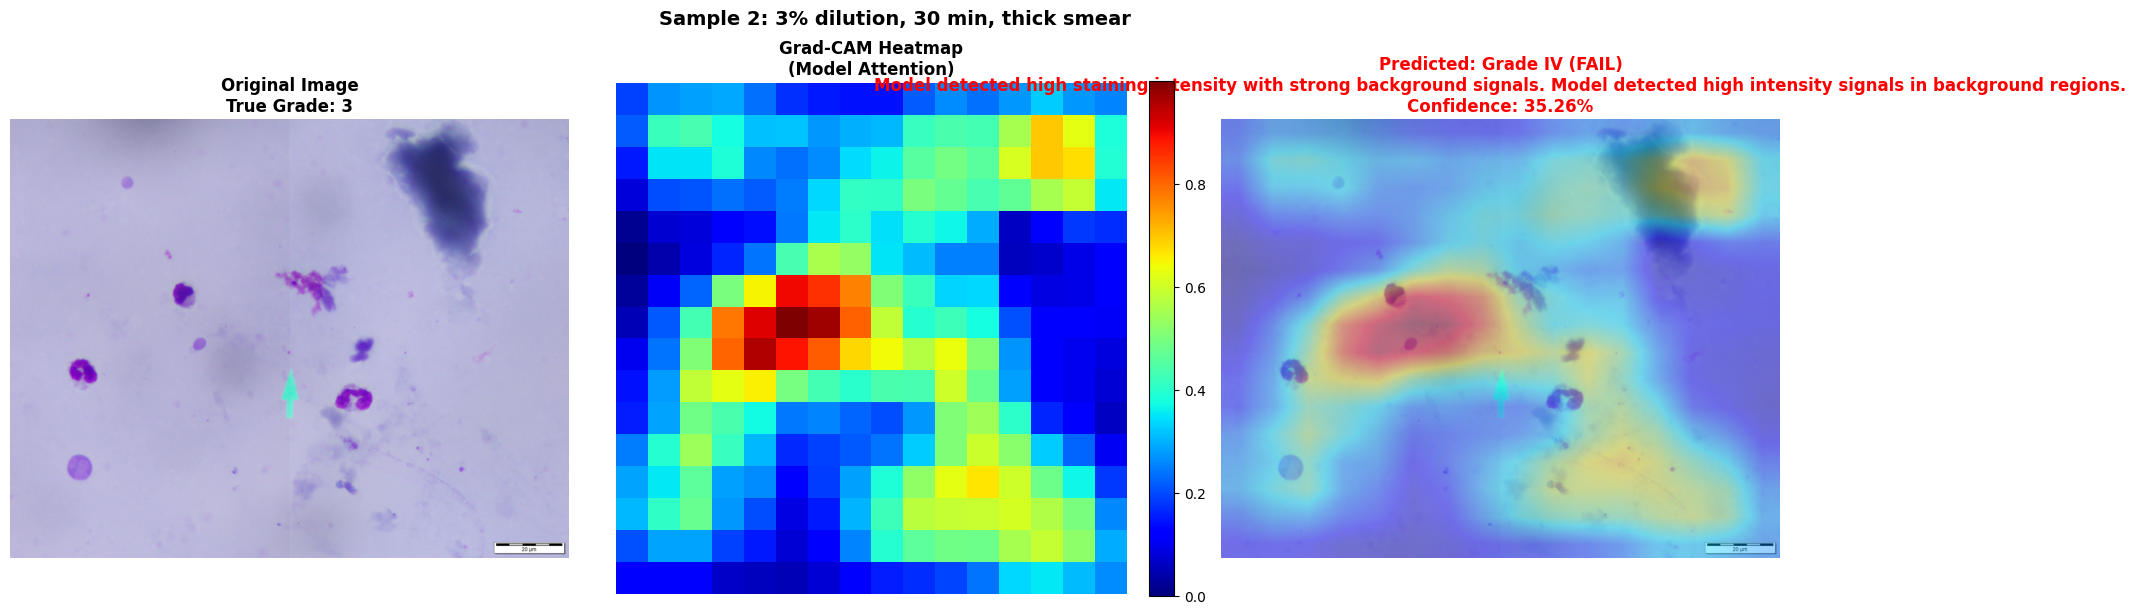


Sample 2 - Probability Breakdown:
  Grade I:  1.65% 
  Grade II: 14.65% ███████
  Grade III: 19.69% █████████
  Grade IV: 35.26% █████████████████
  Grade V: 28.75% ██████████████

✓ Saved to: ..\results\results_04\figures\gradcam\gradcam_notebook\sample_3_grade4_20260101_213342.png


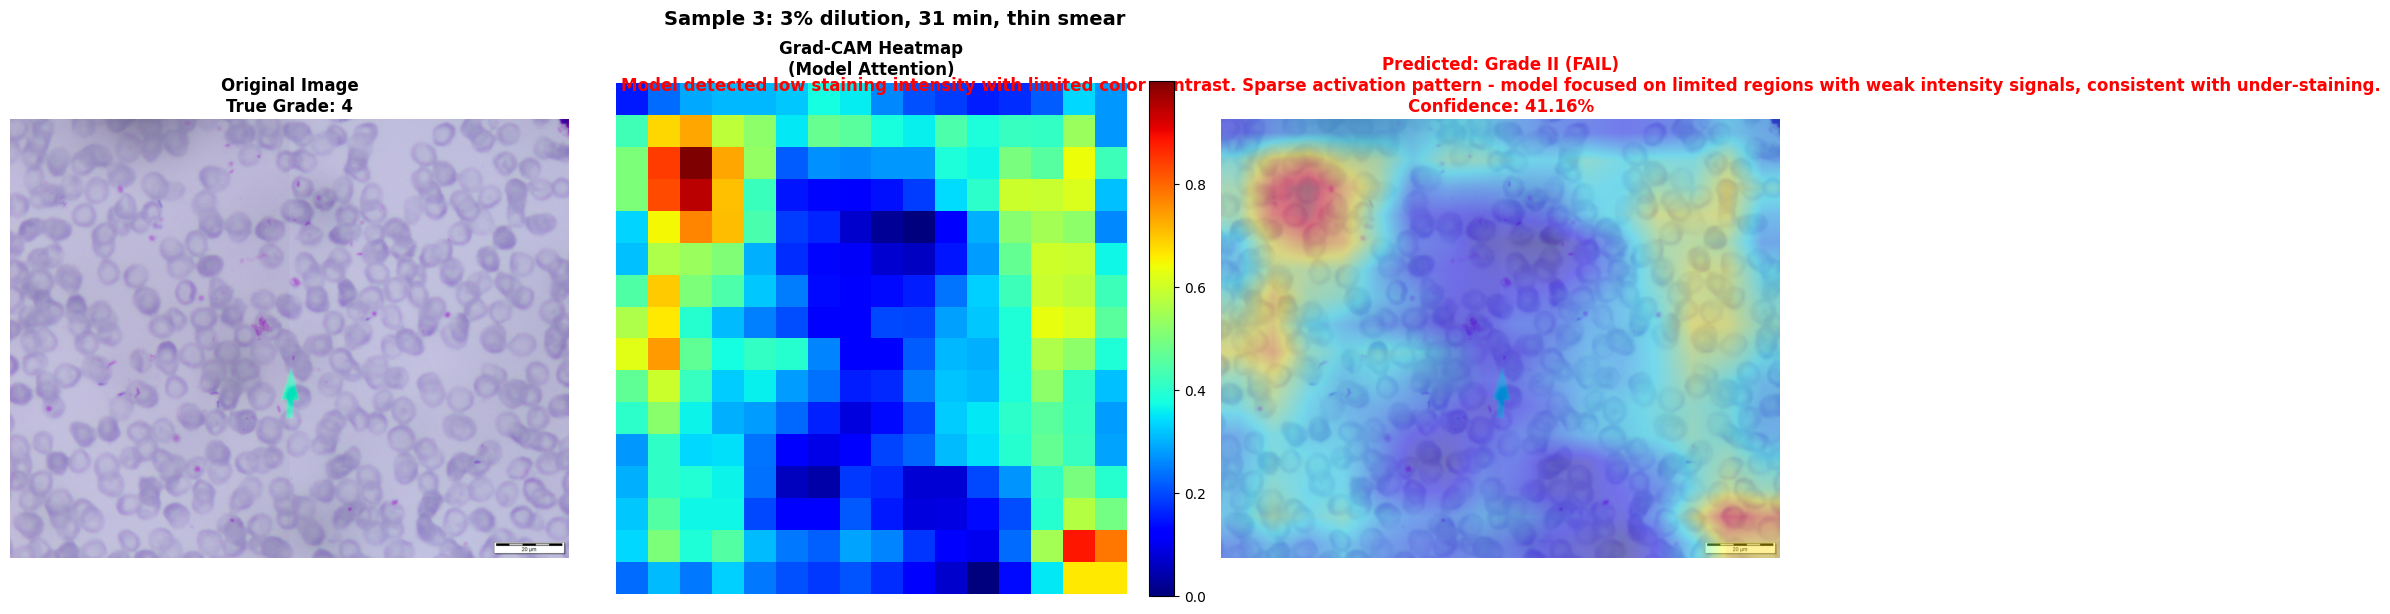


Sample 3 - Probability Breakdown:
  Grade I:  1.82% 
  Grade II: 41.16% ████████████████████
  Grade III: 12.46% ██████
  Grade IV: 23.67% ███████████
  Grade V: 20.88% ██████████

✓ Saved to: ..\results\results_04\figures\gradcam\gradcam_notebook\sample_4_grade5_20260101_213350.png


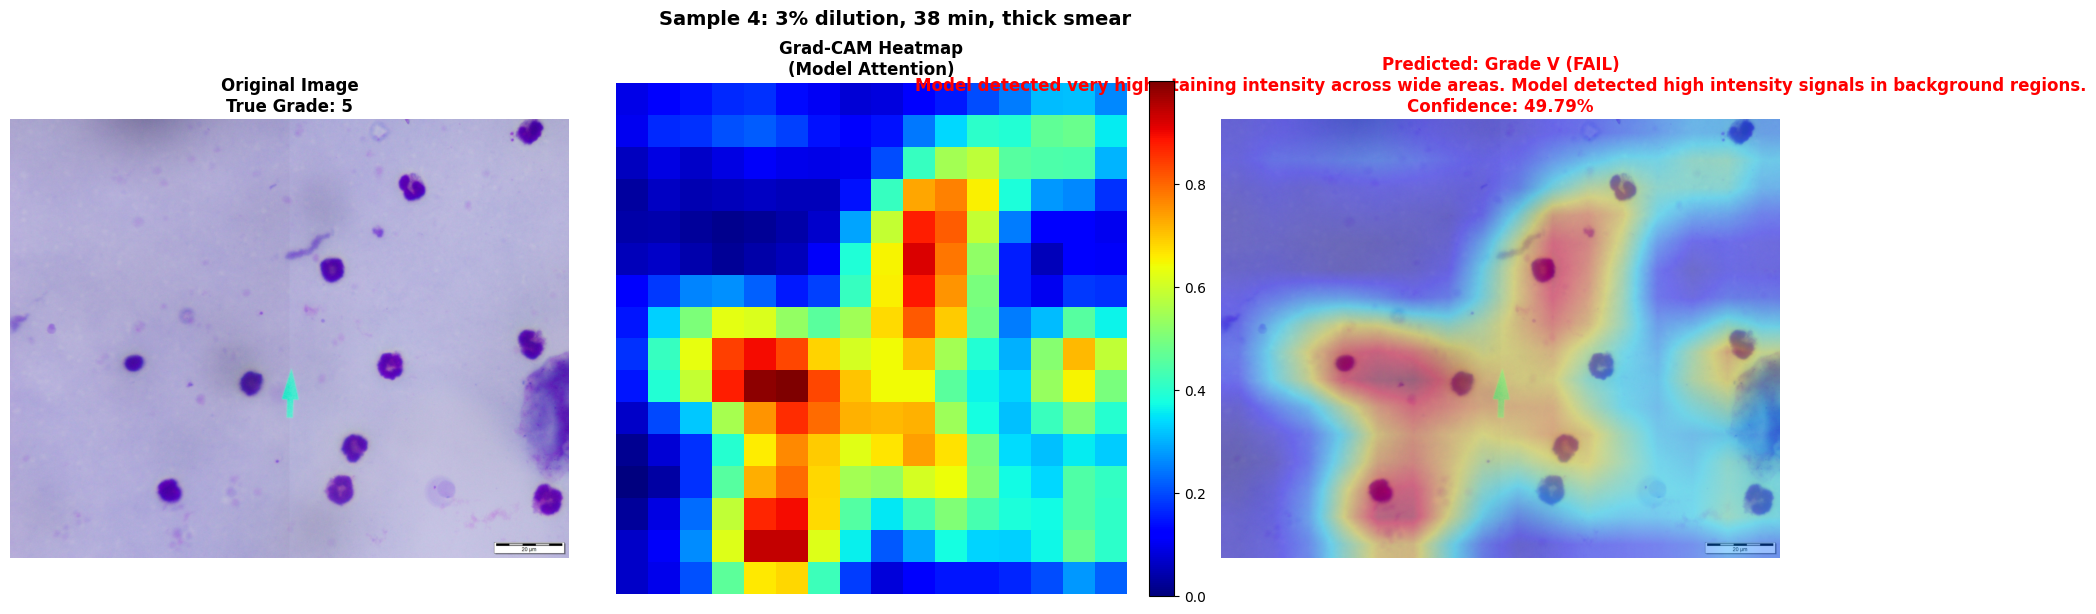


Sample 4 - Probability Breakdown:
  Grade I:  0.14% 
  Grade II:  3.21% █
  Grade III:  3.20% █
  Grade IV: 43.66% █████████████████████
  Grade V: 49.79% ████████████████████████



In [5]:
# Create visualization for each sample
for idx, result in enumerate(explanations):
    sample = result['sample']
    image_np = result['image']
    explanation = result['explanation']
    stain_time = result['stain_time']
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original image
    axes[0].imshow(image_np)
    axes[0].set_title(
        f"Original Image\nTrue Grade: {sample['grade_numeric']}",
        fontsize=12, fontweight='bold'
    )
    axes[0].axis('off')
    
    # Grad-CAM heatmap
    im = axes[1].imshow(explanation['cam_heatmap'], cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap\n(Model Attention)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Overlay
    axes[2].imshow(explanation['overlay_image'])
    status_color = 'green' if explanation['status'] == 'PASS' else 'red'
    axes[2].set_title(
        f"Predicted: Grade {explanation['grade_label']} ({explanation['status']})\n"
        f"{explanation['reason']}\n"
        f"Confidence: {explanation['confidence']:.2%}",
        fontsize=12, fontweight='bold', color=status_color
    )
    axes[2].axis('off')
    
    # Get sample info
    dilution = sample['dilution'] if 'dilution' in sample else 'Unknown'
    smear_type = sample['smear_type'] if 'smear_type' in sample else 'Unknown'
    
    plt.suptitle(
        f"Sample {idx+1}: {dilution} dilution, {stain_time} min, {smear_type} smear",
        fontsize=14, fontweight='bold', y=1.02
    )
    
    plt.tight_layout()
    
    # Save figure
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_path = OUTPUT_DIR / f"sample_{idx+1}_grade{sample['grade_numeric']}_{timestamp}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved to: {save_path}")
    
    plt.show()
    
    # Print probability breakdown
    print(f"\nSample {idx+1} - Probability Breakdown:")
    for i, prob in enumerate(explanation['probabilities']):
        grade_label = ['I', 'II', 'III', 'IV', 'V'][i]
        bar = '█' * int(prob * 50)
        print(f"  Grade {grade_label}: {prob:6.2%} {bar}")
    print()

## 6. Test on Custom Image (Optional)

Loading custom image: ../data/data_04/processed/batch01_10%_10min_3_thin.jpg
Stain time: 10.0 minutes
✓ Saved to: ..\results\results_04\figures\gradcam\gradcam_notebook\custom_batch01_10%_10min_3_thin_20260101_213358.png


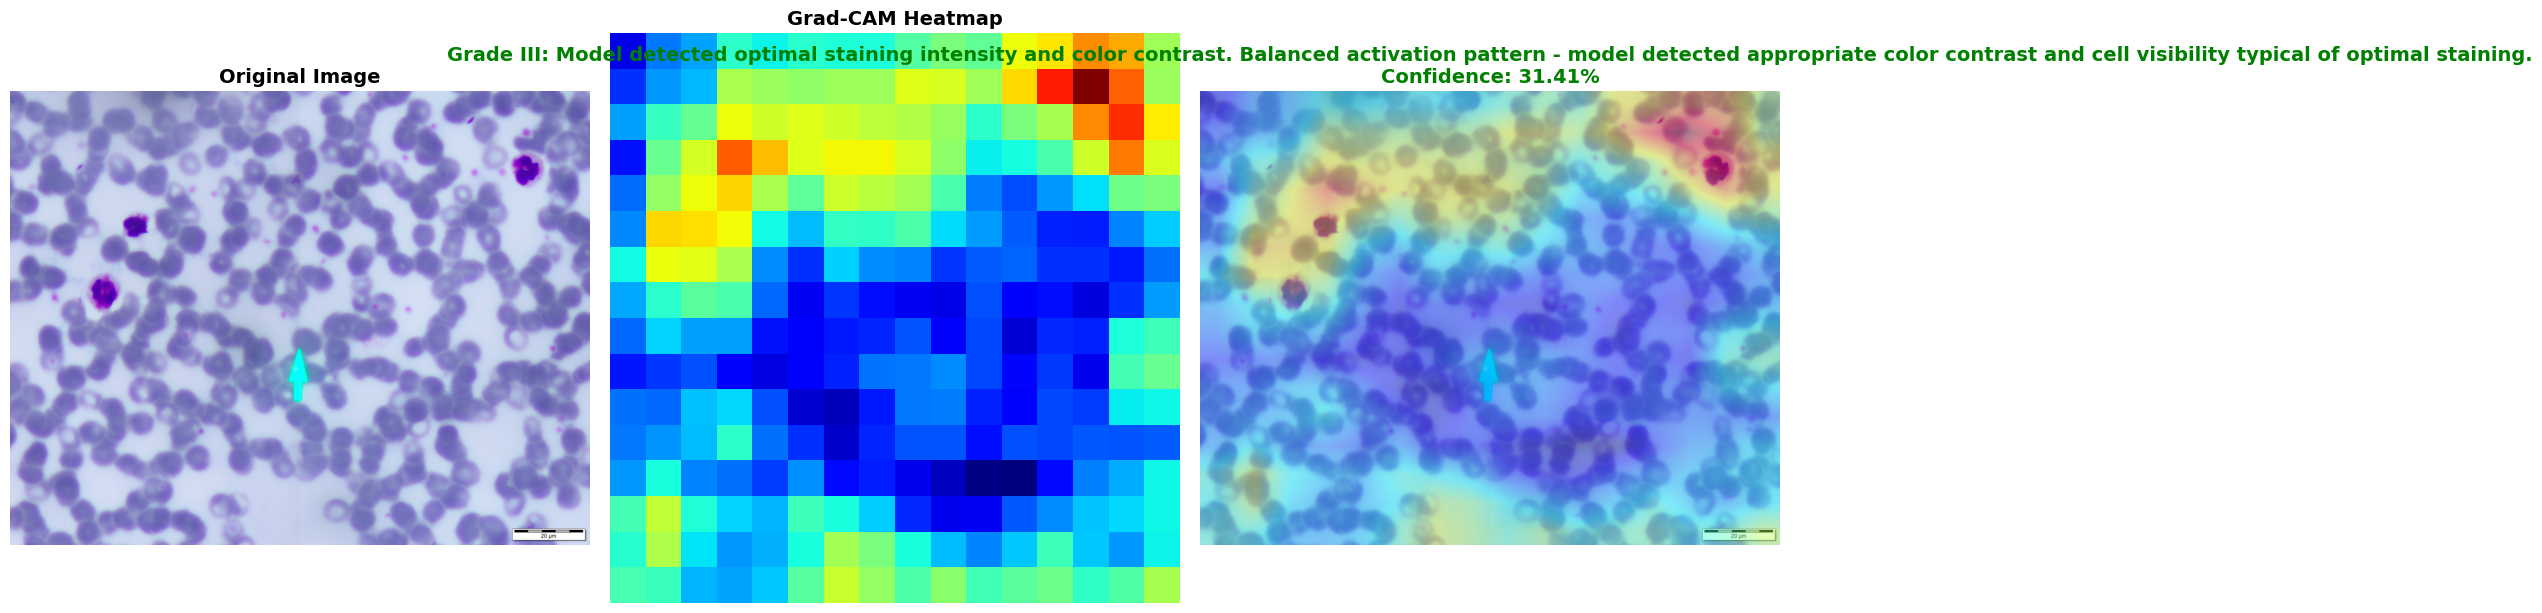


Prediction Results:
  Grade: III (3)
  Status: PASS
  Confidence: 31.41%
  Reason: Model detected optimal staining intensity and color contrast. Balanced activation pattern - model detected appropriate color contrast and cell visibility typical of optimal staining.

Probability Breakdown:
  Grade I:  2.30% █
  Grade II: 21.35% ██████████
  Grade III: 31.41% ███████████████
  Grade IV: 27.25% █████████████
  Grade V: 17.70% ████████


In [6]:
# Specify your custom image path and stain time here
CUSTOM_IMAGE_PATH = '../data/data_04/processed/batch01_10%_10min_3_thin.jpg'
CUSTOM_STAIN_TIME = 10.0  # Stain time in minutes

# Load and process
if Path(CUSTOM_IMAGE_PATH).exists():
    print(f"Loading custom image: {CUSTOM_IMAGE_PATH}")
    print(f"Stain time: {CUSTOM_STAIN_TIME} minutes")
    
    image = Image.open(CUSTOM_IMAGE_PATH).convert('RGB')
    image_np = np.array(image)
    image_tensor = transform(image).unsqueeze(0)
    
    # Prepare stain time tensor
    stain_time_tensor = torch.tensor([CUSTOM_STAIN_TIME], dtype=torch.float32)
    
    # Generate explanation
    explanation = explainer.explain(image_tensor, image_np, stain_time_tensor)
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(image_np)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(explanation['cam_heatmap'], cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(explanation['overlay_image'])
    axes[2].set_title(
        f"Grade {explanation['grade_label']}: {explanation['reason']}\n"
        f"Confidence: {explanation['confidence']:.2%}",
        fontsize=14, fontweight='bold',
        color='green' if explanation['status'] == 'PASS' else 'red'
    )
    axes[2].axis('off')
    
    plt.tight_layout()
    
    # Save custom image result
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    image_name = Path(CUSTOM_IMAGE_PATH).stem
    save_path = OUTPUT_DIR / f"custom_{image_name}_{timestamp}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved to: {save_path}")
    
    plt.show()
    
    print(f"\nPrediction Results:")
    print(f"  Grade: {explanation['grade_label']} ({explanation['grade_numeric']})")
    print(f"  Status: {explanation['status']}")
    print(f"  Confidence: {explanation['confidence']:.2%}")
    print(f"  Reason: {explanation['reason']}")
    
    print(f"\nProbability Breakdown:")
    for i, prob in enumerate(explanation['probabilities']):
        grade_label = ['I', 'II', 'III', 'IV', 'V'][i]
        bar = '█' * int(prob * 50)
        print(f"  Grade {grade_label}: {prob:6.2%} {bar}")
else:
    print(f"Image not found: {CUSTOM_IMAGE_PATH}")
    print("Please update CUSTOM_IMAGE_PATH to a valid image path")

---

## Summary

This notebook demonstrated how to use Grad-CAM to explain slide grade predictions:

1. **Visual Explanations**: Heatmaps show which image regions influenced the prediction
2. **Text Explanations**: Simple reason text based on predicted grade
3. **Confidence Scores**: Probability distributions across all grades

### Key Insights:

- **Red/Hot regions**: Areas the model focused on most
- **Blue/Cool regions**: Areas the model ignored
- **For failed slides**: Heatmap often highlights problematic staining regions
- **For passed slides**: Heatmap shows well-stained cellular regions

### Next Steps:

1. **API Integration**: Use `/api/explain-grade` endpoint in your frontend
2. **User Feedback**: Show Grad-CAM overlays to users
3. **Quality Control**: Use explanations to identify systematic issues

---